# **MEDICAL COST PERSONAL DATASETS**

# **Import Library**

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Business Understading**

### **Study Case**

perusahaan asuransi kesehatan mengalami kerugian besar karena sistem yang tidak akurat. berdasarkan analisis dataset yang berisis 1.338 pemegang polis, ditemukan bahwa pelanggan perokok dikenakan biaya aktual yang harus dikeluarkan oleh perusahaan asuransi dan hal ini menyebabkan kerugian besar bagi perusahaan ini sebanyak jutaan rupiah tiap tahunnya karena harus menanggung banyak biasa kesehatan.
contohnya adalah ada beberapa pelanggan perokok yang tidak sehat (seperti sering masuk rumah sakit) biaya kesehatan yang sangat tinggi sehingga perusahaan asuransi mengalami kerugian karena tiap tahunnya membayar biaya kesehatan sangat mahal. disisi lain terdapat anak muda yang tidak merokok dengan hidup sehat, hampir tidak mengeklaim asuransi. tetapi perusahaan asuransi menagih hampir sama seperti perokok tersebut, sehinngga anak muda tersebut merasa rugi dan akhirnnya pindah ke perusahaan asuransi yang harganya lebih murah. hal ini karena perusahaan asuransi ini tidak memperhitungkan perbedaaan resiko kesehatan setiap orang secara detail dan memukul rata setiap orang.

### **Business Objective**

Dengan tunjuan ini kita harus membuat model machine learning yang bisa memprediksikan biaya asuransi dengan akurat setiap profil orang yang mengeklaim asuransi pada perusahaan ini. model ini akan menggunakan data seperti usia, jenis kelamin, BMI, jumlah anak, status merokok, dan wilayah untuk memprediksi berapa biaya asuransi yang seharusnya dibayar. Dengan ini perusahaan asuransi bisa memberikan harga adil terhhadap pelanggan.
Dan keberhasilan ini diukur dari peningkatan akurasi prediksi, pengurangan kerugian perusahaan dan meningkatkan kerugian pelanggan.

## **Asess Situation**

Dataset yang berisi 1.338  data pemegang polis dengan 7 variabel yaitu usia, jenis kelamin, BMI, jumlah anak, status merokok, wilayah, dan biaya asuransi. kualitas data ini sangat baik dengan kelengkapan 100 persen Sekitar 20 persen pelanggan adalah perokok dan lebih dari setengahnya tidak sehat.

## **Project Plan**

**Project Plan**
1. Business Understanding
Memahami masalah bisnis dan tujuan proyek.
2. Data Understanding
Eksplorasi, visualisasi, dan analisis awal data.
3. Data Preparation
Cleaning data dan feature engineering.
4. Modeling
Membangun dan tuning model machine learning.
5. Evaluation
Evaluasi performa dan pilih model terbaik.
6. Deployment
Implementasi model dan monitoring sistem.

## **Analytic  Goals**

**Analytic Goals**

1. Membangun model machine learning untuk memprediksi biaya asuransi kesehatan dengan akurasi tinggi.
2. Target akurasi minimal 85 persen dengan tingkat kesalahan rendah. Mengidentifikasi.
3. Faktor-faktor yang paling berpengaruh terhadap biaya asuransi (status merokok, usia, BMI).
4. Membantu perusahaan memahami profil risiko pelanggan untuk keputusan pricing yang lebih baik.

# **Data Uderstanding**

###**Memuat Dataset**

In [36]:
path ="/content/drive/MyDrive/praktikum avd/insurance.csv"

df = pd.read_csv(path)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [37]:
df.head(20)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [38]:
df.tail(20)

,age,sex,bmi,children,smoker,region,charges
1318,35,male,39.710,4,no,northeast,19496.71917
1319,39,female,26.315,2,no,northwest,7201.70085
1320,31,male,31.065,3,no,northwest,5425.02335
1321,62,male,26.695,0,yes,northeast,28101.33305
1322,62,male,38.830,0,no,southeast,12981.34570
1323,42,female,40.370,2,yes,southeast,43896.37630
1324,31,male,25.935,1,no,northwest,4239.89265
1325,61,male,33.535,0,no,northeast,13143.33665
1326,42,female,32.870,0,no,northeast,7050.02130
1327,51,male,30.030,1,no,southeast,9377.90470


## **Deskripsi Data**

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### **Informasi Dasar**

Terdapat 1338 baris dan 7 kolom pada dataset ini.

### **Informasi Lanjutan**

1. **age** :
      Jumlah baris: 1338
      Tipe data: int64
      Deskripsi: Usia Pemegang Polis

2. **sex** :
      Jumlah baris: 1338
      Tipe data: object
      Deskripsi: Jenis Kelamin

3. **bmi** :
      Jumlah baris: 1338
      Tipe data: float64
      Deskripsi: Indeks Massa Tubuh

4. **children** :
      Jumlah baris: 1338
      Tipe data: int64
      Deskripsi: Jumlah Tanggungan Anak

5. **smoker** :
      Jumlah baris: 1338
      Tipe data: object
      Deskripsi: Status Merokok

6. **region** :
      Jumlah baris: 1338
      Tipe data: object
      Deskripsi: Wilayah Tempat Tinggal
7. **charges** :
      Jumlah baris: 1338
      Tipe data: float64
      Deskripsi: Biaya Klaim Asuransi

### **Informasi Statistik Deskriptif**

In [40]:
df.describe(include='all')


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


1. Count (Kelengkapan Data)
Semua kolom memiliki 1338 data tanpa missing values.

   Kesimpulan :
   Dataset lengkap

----
2. Mean vs Median (Distribusi Data)
   * Kolom Charges
         
          Mean   : 13270.422265
          Median : 9382.033000
    Nilai Rata rata lebih besar dari median.

    Kesimpulan : Distribusi biaya ini tidak normal, terdapat sekelompok kecil yang membuat rata rata tersebut terlihat besar, namun sebenarnya mayoritas orang membayar lebih murah dari rata rata.

   * Kolom children

         Mean   : 1.09
         Median : 1.00
    Distribusi ini cukup normal dan tidak ada nilai yang mengganggu

    Kesimpulan : Mayoritas pemegang polis memiliki sekitar 1 anak tanggungan.

   * Kolom BMI

         Mean   : 30.66
         Median : 30.40
    Distribusi ini cukup normal, mean dan median hampir sama.
    
    Kesimpulan : Tidak ada nilai ekstrem yang mengganggu, mayoritas peserta memiliki BMI sekitar 30 yang masuk kategori obesitas ringan.
    
   * Kolom Age

         Mean   : 39.21
         Median : 39.00
    Distribusi hampir normal dan distribusi usia cukup merata

    Kesimpulan : Peserta asuransi tersebar cukup seimbang dari usia muda hingga tua.

----
3. Minimal dan Maxsimal (Validasi Logika)

   * Kolom Charges
         
          Minimal   : 1121.873900
          Maxsimal  : 63770.428010
    Perbedaan ini normal. kesehatan tergantung pada kondisi masing masing setiap orang

    Kesimpulan : Distribusi biaya ini terlihat normal karena kondisi orang masing masing, pada orang yang sehat atau jarang sakit membuat klaimnya kecil, sedangkan orang yang mempunyai penyakit serius atau butuh operasi bisa menghasilkan tagihan yang besar.

   * Kolom children

         Minimal  : 0.00
         Maxsimal : 5.00
    Distribusi ini cukup normal dan tidak ada nilai yang negatif

    Kesimpulan : ada peserta yang belum punya anak sama sekali, dan paling banyak menanggung 5 anak.

   * Kolom BMI

          Minimal  : 15.96
          Maksimal : 53.13
    Rentang ini masuk akal karena BMI setiap orang memang berbeda tergantung berat dan tinggi badannya.

    Kesimpulan : Tidak ada nilai yang mencurigakan. BMI terendah masih dalam batas wajar dan tertinggi menunjukkan ada peserta dengan obesitas berat.

   * Kolom Age

         Minimal  : 18.00
         Maxsimal : 64.00
    Ini menunjukkan dataset hanya mencakup usia dewasa, kemungkinan karena asuransi ini memang ditujukan untuk individu yang sudah bekerja.

    Kesimpulan : Tidak ada usia di bawah 18 yang bisa jadi anomali, dan batas atas 64 tahun wajar karena biasanya di atas itu sudah masuk kategori lansia dengan skema asuransi yang berbeda.

---

4. Standar Deviasi(std) - Variabilitas Data

    * Kolom Charges
         
          Mean  : 13270.422265
          std   : 12110.011237
   perbedaan ini normal. kesehatan tergantung pada kondisi masing masing setiap orang

    Kesimpulan : Variasi biaya klaim antar peserta sangat tinggi, yang mencerminkan perbedaan kondisi kesehatan masing-masing individu. Ada yang klaimnya kecil karena jarang sakit, ada yang sangat besar karena butuh penanganan medis serius.

   * Kolom children

         Mean  : 1.09
         std   : 1.20
    Distribusi ini cukup normal dan tidak ada nilai yang negatif

    Kesimpulan : Mayoritas peserta memiliki jumlah anak yang tidak terlalu bervariasi, kebanyakan berkisar di angka 0 sampai 2 anak.
    
   * Kolom BMI

         Mean  : 30.66
         std   : 6.10
    Std-nya relatif kecil dibanding mean-nya.

    Kesimpulan : Variasi BMI antar peserta tidak terlalu besar, artinya sebagian besar peserta memiliki BMI yang tidak terlalu jauh dari rata-rata.

   * Kolom Age

         Mean  : 39.21
         std   : 14.05
    Std-nya 14,05 cukup wajar untuk rentang usia 18–64 tahun.

    Kesimpulan : Usia peserta tersebar cukup merata, tidak menumpuk di satu kelompok umur tertentu.


#**Verifikasi Kualitas Data**

## **Data Type check**

In [41]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


Dataset ini punya 7 kolom yang mencakup informasi dasar peserta seperti usia, jenis kelamin, BMI, jumlah anak, status merokok, dan wilayah tinggal, dengan charges atau biaya klaim sebagai variabel utamanya.

## **Incosistent Values**

Incosistent Values untuk memastikan bahwa data set tidak mengalami ketidak konsistenan karena hal ini bisa membuat hasil analisis jadi tidak akurat. Contohnya seperti 'southwest' dan 'southeast' data yang seharusnya satu kelompok malah terbagi dua. Tidak ada inconsistent values yang terdapat pada dataset ini.

**1. Region**

  Pada regoin terdapat 4 nilai yang sudah konsisten

In [42]:
print(df['region'].unique())

['southwest' 'southeast' 'northwest' 'northeast']


**2. Sex**
    
  Pada sex terdapat 2 nilai yang konsisten

In [43]:
print(df['sex'].unique())

['female' 'male']


**3. Smoker**

 Pada smoker hanya 'yes' dan 'no' saja

In [44]:
print(df['smoker'].unique())

['yes' 'no']


## **Missing Values**

Missing values untuk mengecek apakah data tidak terisi pada dataset.
Jika terdapat missing values maka hasil analisis menjadi tidak akurat ataupun bahkan bisa error pada saat diproses.

In [45]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
age,0.0
sex,0.0
bmi,0.0
children,0.0
smoker,0.0
region,0.0
charges,0.0


Semua kolom dalam dataset ini memiliki 1338 data tanpa ada yang kosong. Tidak ada penanganan khusus yang perlu dilakukan karena dataset sudah lengkap 100%.

## **Duplicated Values**

Disini kita bisa melihat data yang muncul lebih dari satu kali membuat analisis dataset ini terlihat banyak padahal itu adalah data yang sama.

In [46]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


Ditemukan 1 baris duplikat dalam dataset ini dengan nilai yang persis sama di semua kolom. Baris tersebut perlu dihapus agar tidak mempengaruhi hasil analisis.

## **Outliers Values**

Outlier untuk mencari nilai yang aneh atau jauh banget dari data yang lainnya.

In [47]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
age,0.000000
bmi,0.672646
children,0.000000
charges,10.388640


Pada kolom age dan children tidak memiliki outlier. pada kolom bmi memiliki 0.672646 yang sangat kecil, sedangkan kolom charges memiliki 10.388640 yang menandakan cukup banyak individu jauh diatas normal.

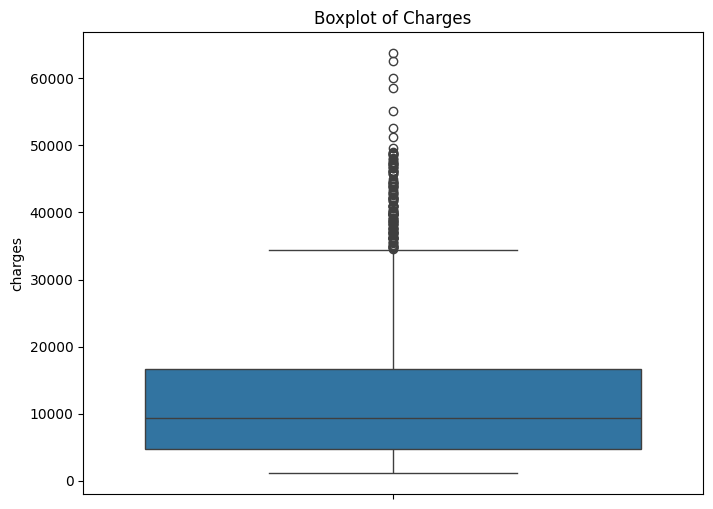

In [48]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['charges'])
plt.title('Boxplot of Charges')
plt.ylabel('charges')
plt.show()

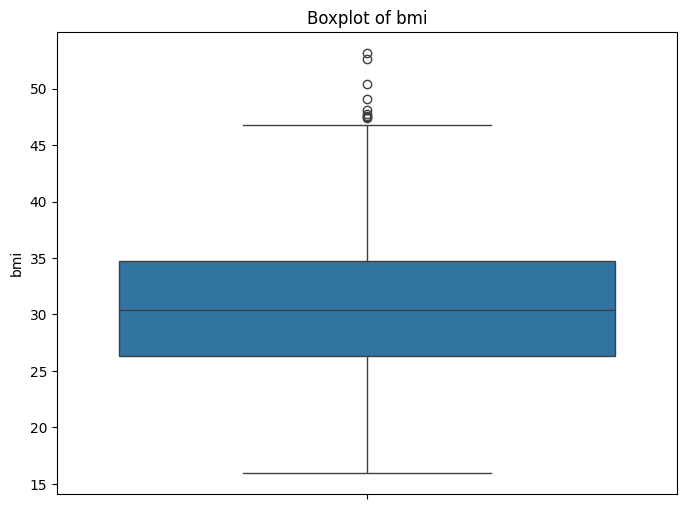

In [49]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['bmi'])
plt.title('Boxplot of bmi')
plt.ylabel('bmi')
plt.show()

# **Eksplorasi Data (EDA)**

###**Comparison/Perbandingan**

Comparison atau perbandingan itu analisis yang digunakan untuk membandingkan nilai antar kelompok atau kategori. Di dataset ini bisa membandingkan rata-rata biaya klaim antara perokok dan non perokok, antara pria dan wanita, atau antar wilayah. Tujuannya untuk melihat kelompok mana yang punya nilai lebih tinggi atau lebih rendah dan seberapa besar perbedaannya.

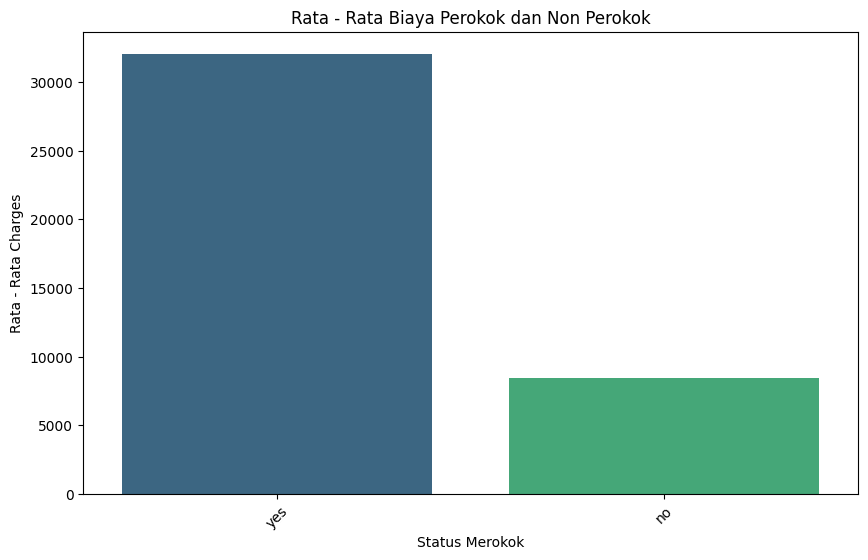

In [50]:
charges_smoker = df.groupby('smoker')['charges'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=charges_smoker.index, y=charges_smoker.values, palette='viridis', hue=charges_smoker.index, legend=False)
plt.title('Rata - Rata Biaya Perokok dan Non Perokok')
plt.xlabel('Status Merokok')
plt.ylabel('Rata - Rata Charges')
plt.xticks(rotation=45)
plt.show()

 Rata-rata Biaya Perokok vs Non-Perokok
Perokok memiliki rata-rata biaya klaim sekitar 32.000, jauh lebih tinggi dibanding non-perokok yang hanya sekitar 8.000.

###**Composition/Komposisi**

Composition atau komposisi ialah analisis yang digunakan untuk melihat bagaimana suatu keseluruhan terbagi menjadi bagian-bagian. Di dataset ini bisa melihat seberapa besar proporsi perokok vs non-perokok, perbandingan jumlah pria dan wanita, atau distribusi peserta per wilayah.

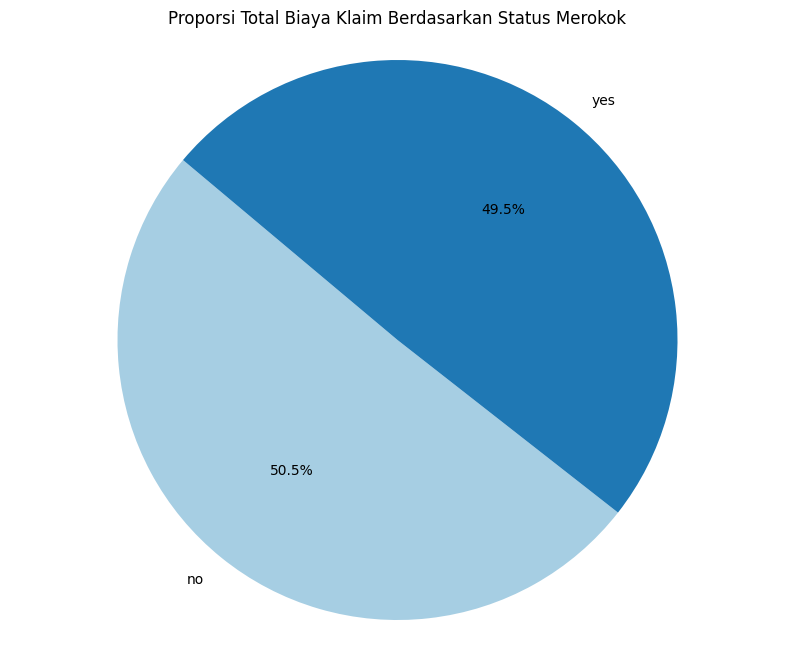

In [51]:
smoker_counts = df.groupby('smoker')['charges'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
smoker_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proporsi Total Biaya Klaim Berdasarkan Status Merokok')
plt.ylabel('')
plt.axis('equal')
plt.show()

Proporsi Biaya Klaim Berdasarkan Status Merokok
Meskipun jumlah perokok jauh lebih sedikit dari non-perokok, proporsi total biaya klaim keduanya hampir seimbang yaitu 49,5% untuk perokok dan 50,5% untuk non-perokok.

### **Distribution/Distribusi**

Distribution atau distribusi itu analisis digunakan untuk melihat bagaimana persebaran nilai dalam satu kolom. Tujuannya untuk mengetahui apakah data terpusat di satu nilai, menyebar merata, atau condong ke satu sisi.

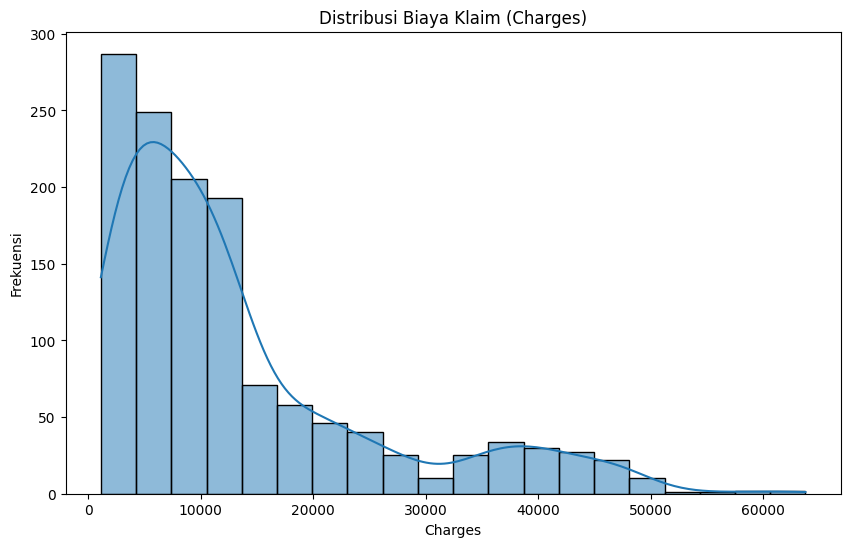

In [52]:
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], bins=20, kde=True)
plt.title('Distribusi Biaya Klaim (Charges)')
plt.xlabel('Charges')
plt.ylabel('Frekuensi')
plt.show()

Dataset tidak normal Distribusi Biaya Klaim
Distribusi charges condong ke kanan (skewed right), mayoritas peserta memiliki biaya klaim di bawah 10.000 namun ada sebagian kecil yang mencapai 60.000 ke atas.

### **Relationship/Hubungan**

Relationship atau hubungan merupakan analisis yang digunakan untuk melihat apakah ada keterkaitan antara dua variabel atau lebih. Di dataset ini bisa melihat apakah BMI yang tinggi berpengaruh pada biaya klaim, atau apakah usia berbanding lurus dengan charges.

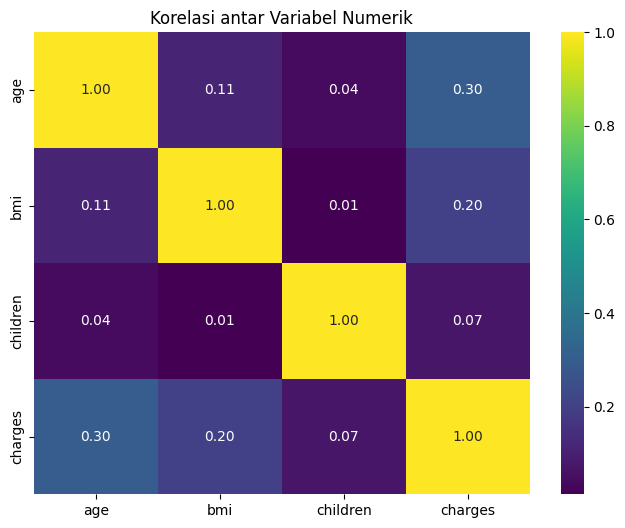

In [53]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['age', 'bmi', 'children', 'charges']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antar Variabel Numerik')
plt.show()

Korelasi antar Variabel Numerik
Korelasi paling kuat adalah antara age dan charges (0.30), artinya semakin tua usia seseorang cenderung semakin besar biaya klaimnya. BMI juga punya korelasi dengan charges (0.20) meski tidak terlalu kuat

# **Data Preparation**

## **Data Type Check**

In [54]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


## **Incosistent Values**

####**1. Region**

In [55]:
print(df['region'].unique())

['southwest' 'southeast' 'northwest' 'northeast']


Pada kolom region terdapat 4 nilai unik dan seluruhnya sudah konsisten.

####**2. Sex**

In [56]:
print(df['sex'].unique())

['female' 'male']


Pada kolom sex terdapat 2 nilai unik dan seluruhnya sudah konsisten.

####**3. Smoker**

In [57]:
print(df['smoker'].unique())

['yes' 'no']


Pada kolom smoker terdapat 2 nilai unik dan seluruhnya sudah konsisten.

## **Missing Values**

In [58]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
age,0.0
sex,0.0
bmi,0.0
children,0.0
smoker,0.0
region,0.0
charges,0.0


Pengecekan missing values dilakukan untuk memastikan tidak ada data yang kosong dalam dataset. Hasilnya, seluruh kolom memiliki nilai 0% missing values, artinya dataset ini sudah lengkap sejak awal.

## **Duplicated**

In [62]:
df = df.drop_duplicates()

In [63]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges


Setelah dilakukan penghapusan data duplikat, terdapat satu  baris duplikat yang ditemukan pada saat pengecekan verifikasi kualitas data.
Baris duplikat memiliki data pemegang polis berjenis kelamin laki laki (male) berusia 58 tahun, dengan bmi 30.59, memiliki 1 anak, tidak merokok (no), berasal dari wilayah northwest, dan memiliki biaya asuransi seberas 1.639,56. Data ini dihapus karena memiliki nilai yang persis sama di semua kolom dengan baris lainnya.

##**Outliers Values**

In [65]:
columns_to_impute = ["bmi"]

for col in columns_to_impute:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menggunakan .loc[] agar tidak muncul SettingWithCopyWarning
    df.loc[:, col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [66]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
age,0.00000
bmi,0.00000
children,0.00000
charges,10.39641


 Setelah melakukan penaganan outliers, Pada kolom bmi berhasil ditengani. pada kolom charges masih memiliki outliers sebesar 10.39% hal ini bisa dikatakan wajar karena biaya asuransi kesehatan memang sangat bervariasi, tergantung faktor usia, kebiasaan merokok, dan kondisi kesehatan seseorang. nilai tersebut bukan merupakan kesalahan data, melainkan kondisi nyata di lapangan.

# **Construct Data**

Pada tahap ini tidak dilakukan penambahan variabel baru karena seluruh fitur yang dibutuhkan untuk analisis dan pemodelan sudah tersedia dalam dataset, yaitu age, sex, bmi, children, smoker, region, dan charges.

# **Data Reduction**

Pada tahap ini tidak dilakukan pengurangan data karena dataset hanya memiliki 7 kolom dan seluruh variabel tersebut relevan untuk proses analisis dan prediksi biaya asuransi kesehatan.

# **Menyimpan Dataset**

In [59]:
output_path = "/content/drive/MyDrive/praktikum avd/insurance(clean).xlsx"

df.to_excel(output_path, index=False)

In [60]:
df.to_csv('[Bersih]/content/drive/MyDrive/praktikum avd/insurance.csv', index=False)

OSError: Cannot save file into a non-existent directory: '[Bersih]/content/drive/MyDrive/praktikum avd'